# MiniProjet: Le réchauffement climatique

Dans ce cprojet, on cherche à mettre en évidence un rechauffement progressif à partir des mesures locales de température lors du dernier siècle.  
On divisera cette mise en évidence en deux parties:
- Dans la première on cherchera à ajuster un modèle d'oscillation seasonières de température aux données. En appliquant ce modèle/ajustement à chaque décennie on pourra estimer l'évolution de la température moyenne décénnale.
- Dans une deuxième partie on cherchera à mieux affiner le modèle et à inclure un paramètre qui puisse montrer une possible augmentation linéaire de la température moyenne.

In [1]:
# Import des modules
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [2]:
# Constantes
omega   = 2 * np.pi  # en rad/an
sigma_T = 5          # en °C

### Modèles

In [3]:
def model1 (t, A, B, phi):
    "Modèle sinusoïdale des variations de température"
    T_ = A*np.sin(omega*t + phi) + B
    return T_

In [4]:
def model2 (t, A, B, C, phi):
    "Modèle sinusoïdale avec accroissement linéaire de température"
    T_ = A*np.sin(omega*t + phi) + B + C*t
    return T_

## Ajustement avec le 1er modèle

In [5]:
# Lecture des données
data = np.loadtxt('montelimar_temperature.dat')

On devrait trouver le données suivants:
- colonne 1 : date en MJD (*modified Julian Day*)
- colonne 2 : température en degrés Celsius

In [6]:
# Mise en forme des données
print(data.shape)
data = data.T
print(data.shape)

(36295, 2)
(2, 36295)


### Mise en forme des données

In [7]:
# Réglage d'unités
time_jours     = data[0]
time_j_origin0 = time_jours-time_jours[0]
time_y_origin0 = time_j_origin0/365

# Filtrage en décennies
time_per_dec = time_y_origin0//10
print(time_per_dec)

[0. 0. 0. ... 9. 9. 9.]


In [8]:
# Division des plages de temps en decennies
time10 = []
temp10 = []
for i in range(0,10):
    condition = (time_per_dec == i)
    time_10 = (time_y_origin0)[condition]
    temp_10 = (data[1])[condition]
    #print(len(time_10))
    
    time10.append(time_10)
    temp10.append(temp_10)

Sachant que les mesures commencent en 1920 on rétablit l'origine de temps:

In [9]:
# Mise en dates
plot_time = time_y_origin0 + 1920

### Fit pour toute la plage de temps

Maintenant on réalisera un ajustement sinusoïdale des données. Cet ajustement cependant ne nous permettra pas d'aprécier una augmentation de la température globale car le paramètre renvoyé par la fonction représente une température moyenne de toute la plage de temps.

In [11]:
# Fit
sigmas_T = sigma_T*np.ones(len(data[1])) 
params, cov = curve_fit(model1, time_y_origin0, data[1], sigma = sigmas_T)

A_fit1 = params[0]
B_fit1 = params[1]
phi_fit1 = params[2]

param_err1 = np.sqrt(np.diag(cov))
    
A_err1 = param_err1[0]
B_err1 = param_err1[1]
phi_err1 = param_err1[2]

##### Plot

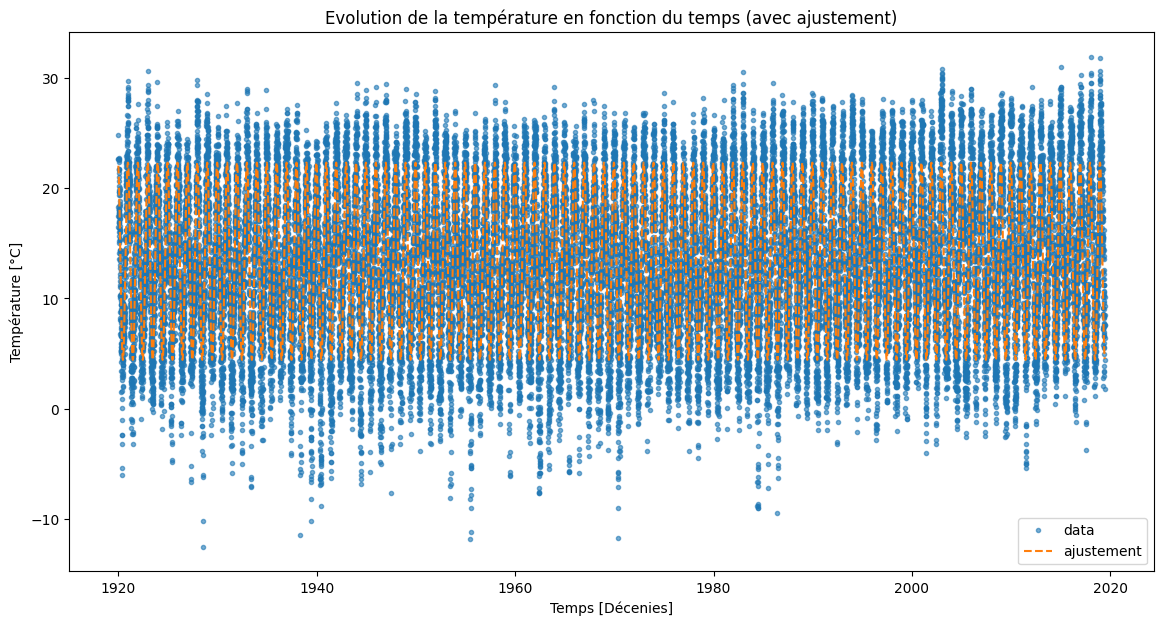

In [12]:
# Temps donne par le fit
temp1_fit = model1(time_y_origin0, A_fit1, B_fit1, phi_fit1)

# Plot
plt.figure(figsize=(14,7))

plt.plot(plot_time, data[1],'.', alpha = 0.6, label = 'data')
plt.plot(plot_time, temp1_fit, '--', label = 'ajustement')
plt.title("Evolution de la température en fonction du temps (avec ajustement)")
plt.xlabel('Temps [Décenies]')
plt.ylabel('Température [°C]')
plt.legend()

Si on observe pour quelques décennies:

(1940.0, 1960.0)

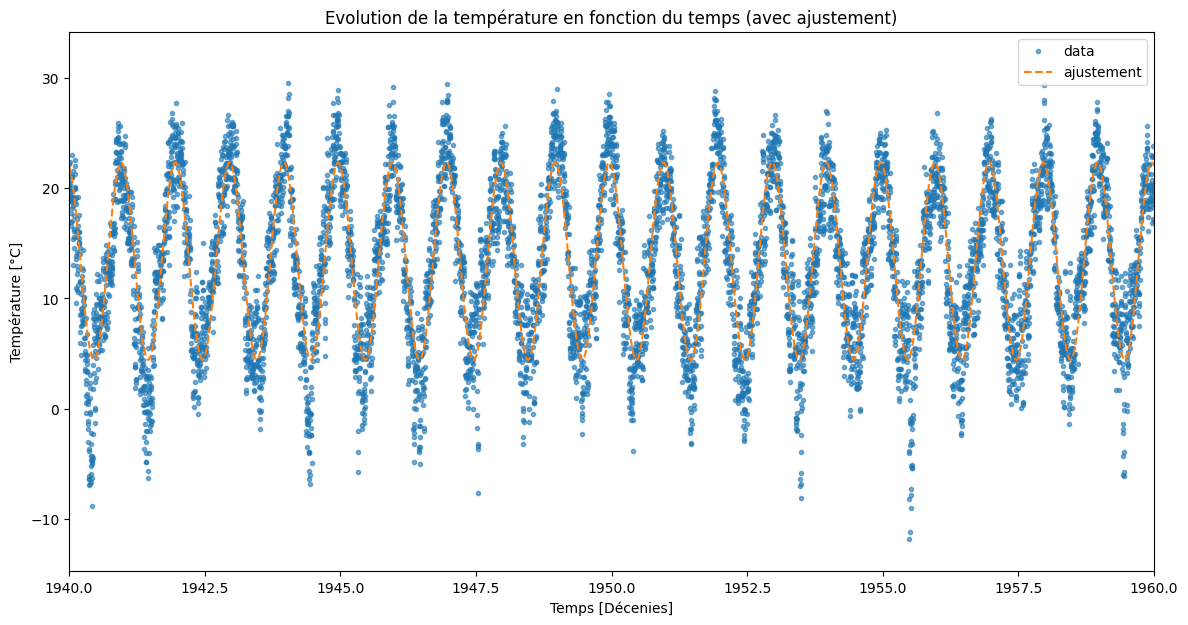

In [13]:
# Plot
plt.figure(figsize=(14,7))

plt.plot(plot_time, data[1],'.', alpha = 0.6, label = 'data')
plt.plot(plot_time, temp1_fit, '--', label = 'ajustement')
plt.title("Evolution de la température en fonction du temps (avec ajustement)")
plt.xlabel('Temps [Décenies]')
plt.ylabel('Température [°C]')
plt.legend()
plt.xlim(1940,1960)

On voit que le modèle s'ajuste assez bien aux données, sauf dans les dernières deccennies où on peut remarquer une légère déviation vers le haut du sinus. Cette observation nous suggère une augmentation progressive de la température moyenne. On étudiera cet aspect dans la deuxième partie.

### Fits pour chaque décénie

In [14]:
# Fit des 10 décennies
A_fits   = np.ones(10)
B_fits   = np.ones(10)
phi_fits = np.ones(10)

A_err    = np.ones(10)
B_err    = np.ones(10)
phi_err  = np.ones(10)

for i in range(len(time10)):
    sigmas_T = sigma_T * np.ones(temp10[i].size)
    param, cov = curve_fit(model1, time10[i], temp10[i], sigma = sigmas_T)
    
    A_fits[i] = param[0]
    B_fits[i] = param[1]
    phi_fits[i] = param[2]
    
    # Calcul de l'incertitude sur les paramètres ajustés
    param_err = np.sqrt(np.diag(cov))
    
    A_err[i] = param_err[0]
    B_err[i] = param_err[1]
    phi_err[i] = param_err[2]

### Evolution de la température moyenne

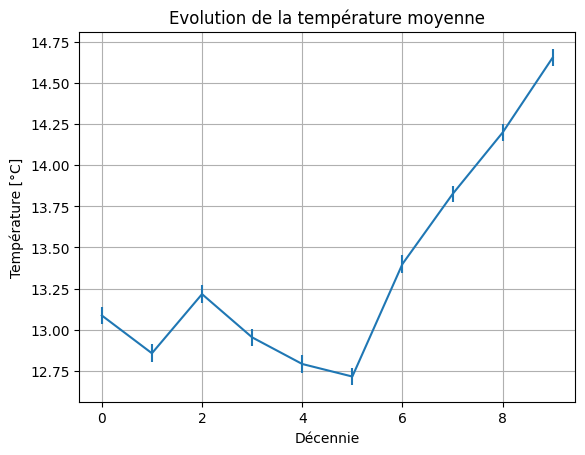

In [15]:
# Plot de l'évolution de la température moyenne avec incertitudes de calcul
plt.errorbar(range(0,10), B_fits, B_err)
plt.title("Evolution de la température moyenne")
plt.xlabel("Décennie"); plt.ylabel("Température [°C]")
plt.grid()
plt.show()

On voit bien que la température moyenne dans les dernières décénies augmente notablement au délà des oscillations appercues dans les premières décennies.

## Ajustement avec le 2eme modèle

On applique un deuxième ajustement à tous les données. On cherche à voir s'il y a un accroissement linéaire de la température moyenne.

In [16]:
# Ajustement avec les deuxième modèle
sigmas_T2 = sigma_T*np.ones(len(data[1])) 
params2, cov2 = curve_fit(model2, time_y_origin0, data[1], sigma = sigmas_T2)

A_fit2 = params2[0]
B_fit2 = params2[1]
C_fit2 = params2[2]
phi_fit2 = params2[3]

# Incertitudes associées
param_err2 = np.sqrt(np.diag(cov2))

A_err2 = param_err2[0]
B_err2 = param_err2[1]
C_err2 = param_err2[2]
phi_err2 = param_err2[3]

In [17]:
print("Température moyenne: {:.3f} \nTaux d'accroissement de la température moyenne: {:.3f}".format(B_fit2, C_fit2))

Température moyenne: 12.513 
Taux d'accroissement de la température moyenne: 0.017


On remarque bien que l'évolution de température moyenne est positive. Si bien faible, le fait qu'il y ait un taux d'accroissement positif implique que il y a une augmentation progressive de la température moyenne.

On devra alors déterminer si cet accroissement positif est réel ou contenu dans le cadre des fluctuations statistiques.

### Caractère significatif du rechauffement

Afin de mettre en évidence le caractère significatif du rechauffement on peut comparer la valeure $C$ de l'accroissement donné par le fit et son erreur statistique.

In [18]:
# Comparation taux d'accroissement et incertitude associée
print("Taux d'accroissement de la température moyenne: {:.8f} \nErreur statistique sur le taux d'accroissement: {:.8f}".format(C_fit2, C_err2))
ecart_relatif = abs(C_fit2 - C_err2) / C_fit2
print("Écart relatif à la fluctuation statistique: {:.3f}".format(ecart_relatif))


Taux d'accroissement de la température moyenne: 0.01721062 
Erreur statistique sur le taux d'accroissement: 0.00059909
Écart relatif à la fluctuation statistique: 0.965


Étant donné que la valeure du taux d'accroissement est déviée de 0 bien plus de la valeure de son incertitude on peut conclure que cette tendance positive n'est pas due à des fluctuations statistiques mais à une tendance bien réelle.

### Plot données et ajustement par le 2ème modèle

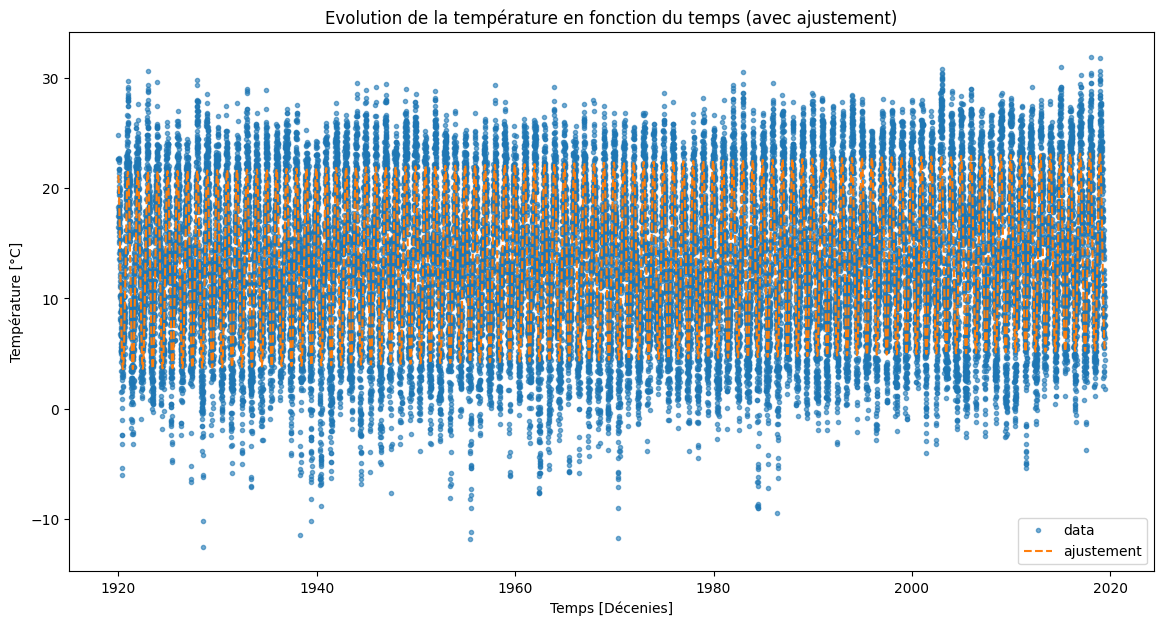

In [19]:
# Ajustement donné par le fit
temp2_fit = model2(time_y_origin0, A_fit2, B_fit2, C_fit2, phi_fit2)

# Plot
plt.figure(figsize=(14,7))

plt.plot(plot_time, data[1],'.', alpha = 0.6, label = 'data')
plt.plot(plot_time, temp2_fit, '--', label = 'ajustement')
plt.title("Evolution de la température en fonction du temps (avec ajustement)")
plt.xlabel('Temps [Décenies]')
plt.ylabel('Température [°C]')
plt.legend()
#plt.xlim(0,20)

On observe pour quelques décennies:

(1920.0, 1950.0)

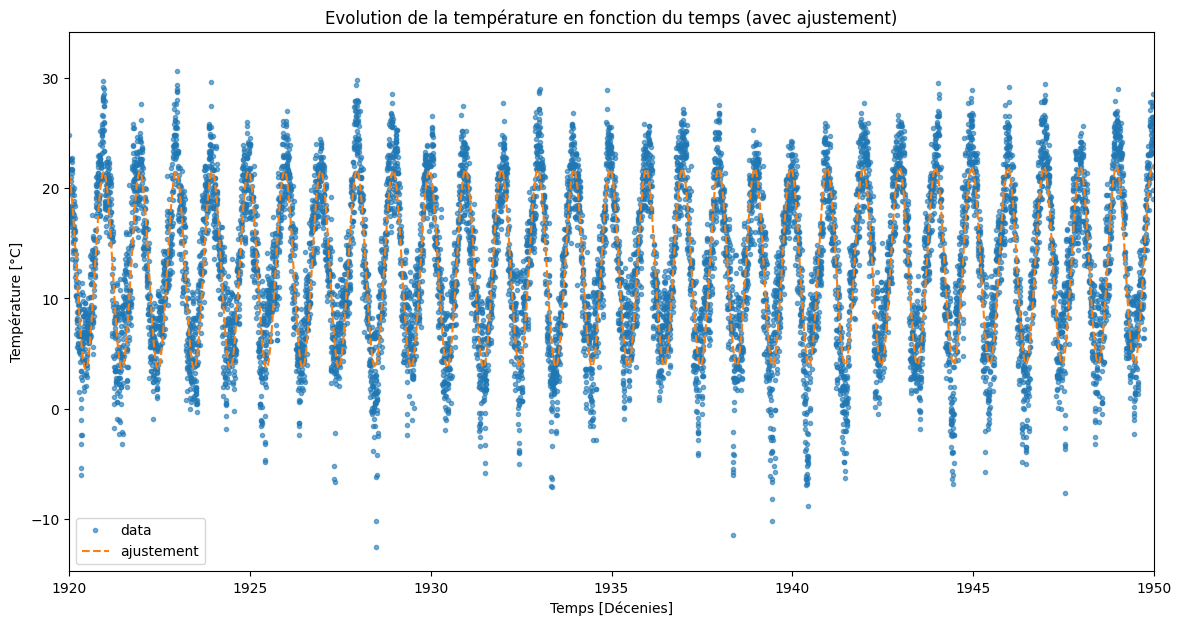

In [20]:
# Replot de 3 décennies
plt.figure(figsize=(14,7))

plt.plot(plot_time, data[1],'.', alpha = 0.6, label = 'data')
plt.plot(plot_time, temp2_fit, '--', label = 'ajustement')
plt.title("Evolution de la température en fonction du temps (avec ajustement)")
plt.xlabel('Temps [Décenies]')
plt.ylabel('Température [°C]')
plt.legend()
plt.xlim(1920,1950)

On observe que le modèle qui prend en compte une augmentation linéaire de la température moyenne s'ajuste encore mieux aux données.